In [2]:
# ---------------------------------------
# 1. Import Library
# ---------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# ---------------------------------------
# 2. Load Dataset
# ---------------------------------------
df = pd.read_csv(r"C:\Users\BINTANG PANDU\Downloads\archive\Mall_Customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# ---------------------------------------
# 3. Pilih Fitur untuk Clustering
# Biasanya: Annual Income & Spending Score
# ---------------------------------------
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standarisasi (opsional tetapi disarankan)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


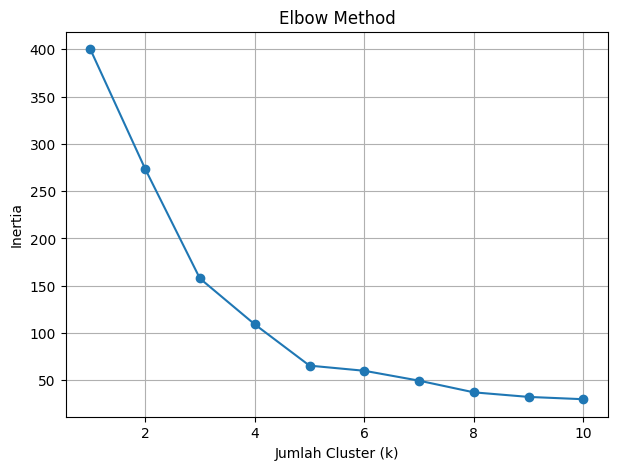

In [4]:
# ---------------------------------------
# 4. Menentukan Jumlah Cluster (Elbow Method)
# ---------------------------------------
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [5]:
# ---------------------------------------
# 5. Training K-Means dengan K cluster
# Misal hasil Elbow = 5 cluster
# ---------------------------------------
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


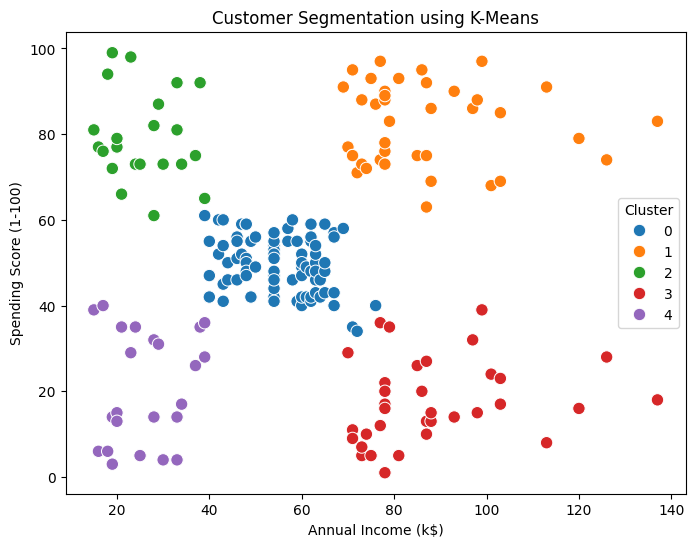

In [6]:
# ---------------------------------------
# 6. Visualisasi Cluster (2D Plot)
# ---------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='tab10',
    s=80
)

plt.title("Customer Segmentation using K-Means")
plt.show()


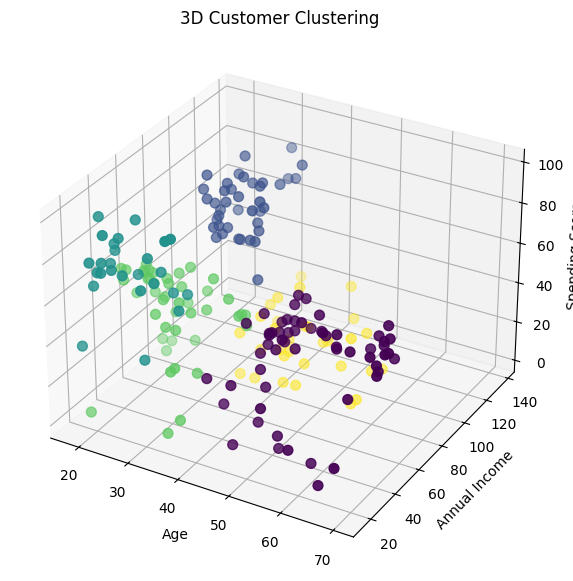

In [7]:
# ---------------------------------------
# 7. Visualisasi 3D (Jika ingin)
# Menggunakan Age juga
# ---------------------------------------
from mpl_toolkits.mplot3d import Axes3D

X3D = df[['Age','Annual Income (k$)', 'Spending Score (1-100)']]
X3D_scaled = scaler.fit_transform(X3D)

kmeans3d = KMeans(n_clusters=5, random_state=42)
df['Cluster3D'] = kmeans3d.fit_predict(X3D_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
    c=df['Cluster3D'], s=50
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income")
ax.set_zlabel("Spending Score")
ax.set_title("3D Customer Clustering")

plt.show()


In [8]:
# ---------------------------------------
# 8. Menyimpan hasil cluster ke file CSV
# ---------------------------------------
df.to_csv("Customer_Cluster_Result.csv", index=False)
print("File hasil cluster berhasil disimpan!")


File hasil cluster berhasil disimpan!
